### LIN371 Project Code
* Narrative-Based Wernicke's Aphasia Binary Classifier Using Clinical and Textual Features
* Jada Li, Aaron Coronado, Andrea Conde

In [1]:
# import libraries
import pandas as pd
import glob
import os
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from scipy.sparse import csr_matrix

#### Preprocessing

In [2]:
# load patient plaintext files
data = []

for file in glob.glob("plaintext/*.txt"):
    file_id = os.path.basename(file).replace("_plain.txt", "")

    with open(file, "r") as f:
        text = f.read().strip()
    data.append({"id": file_id, "text": text})

df_text = pd.DataFrame(data)

# load clinical data
df_clinical = pd.read_csv("english-results-data.csv")

In [3]:
# clean ids
df_text["id"] = df_text["id"].str.strip().str.lower()
df_clinical["id"] = df_clinical["id"].str.strip().str.lower()

# merge with df_text on id
df = pd.merge(df_text, df_clinical, on="id")

# label creation
df["WAB Type"] = df["WAB Type"].str.lower().str.contains("wernicke").astype(int)

In [4]:
# define clinical features and drop unavailable data
clinical_features = [
    "WAB SpontSp Fluency",
    "WAB SpontSp InfoContent",
    "WAB Repetition",
    "WAB AudWdRec",
    "WAB Object Naming"
]

df = df.loc[:, ['id', 'WAB Type', 'text', 
           'WAB SpontSp Fluency', 
           'WAB SpontSp InfoContent',
           'WAB Repetition', 
           'WAB AudWdRec',
           'WAB Object Naming']]

df[clinical_features] = df[clinical_features].replace("U", pd.NA)
df[clinical_features] = df[clinical_features].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=clinical_features)

In [5]:
# define features and labels
text_feature = "text" #df["text"]
label = "WAB Type"

In [6]:
df["WAB Type"].value_counts()

WAB Type
0    283
1     25
Name: count, dtype: int64

#### Train/Test Split

In [7]:
# train/test split 

# 85%-15%
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(
    df,
    test_size=0.15,
    stratify=df[label],
    random_state=42
)

# #Train-Temp 70%-30% split
# df_train, df_temp = train_test_split(
#     df,
#     test_size=0.30,
#     stratify=df[label],
#     random_state=42
# )

# # Validation-Test 50%-50% split
# df_val, df_test = train_test_split(
#     df_temp,
#     test_size=0.50,   # half of 30% = 15%
#     stratify=df_temp[label],
#     random_state=42
# )

y_train = df_train[label]
y_test = df_test[label]
# y_val = df_val[label]

In [8]:
# preprocessing + model pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=2), text_feature),
        ("clin", StandardScaler(), clinical_features)
    ]
)

lr_model = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(class_weight="balanced"))
])

svm_model = Pipeline([
    ("preprocess", preprocess),
    ("clf", LinearSVC(class_weight="balanced"))
])

In [9]:
# cross-validation on training set only
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(
    lr_model,
    df_train,
    y_train,
    cv=skf,
    scoring="f1_macro"
)

svm_cv_scores = cross_val_score(
    svm_model,
    df_train,
    y_train,
    cv=skf,
    scoring="f1_macro"
)

print("LR Cross-Validation scores:\n", lr_cv_scores)
print("LR Cross-Validation mean:\n", lr_cv_scores.mean())
print("----------------------------------------------------------------")
print("SVM Cross-Validation scores:\n", svm_cv_scores)
print("SVM Cross-Validation mean:\n", svm_cv_scores.mean())

LR Cross-Validation scores:
 [0.80586081 0.6494382  0.54252199 0.74584555 0.77025037]
LR Cross-Validation mean:
 0.7027833845457143
----------------------------------------------------------------
SVM Cross-Validation scores:
 [0.72959184 0.55744681 0.46391753 0.6462585  0.82312925]
SVM Cross-Validation mean:
 0.6440687852241138


In [10]:
# train final model
lr_model.fit(df_train, y_train)
svm_model.fit(df_train, y_train)

# Test evaluation (final report)
lr_y_pred = lr_model.predict(df_test)
svm_y_pred = svm_model.predict(df_test)

# print results
print("LR Cross-Validation scores:", lr_cv_scores)
print("LR Cross-Validation mean:", lr_cv_scores.mean())
print("LR TEST PERFORMANCE")
print(classification_report(y_test, lr_y_pred, zero_division=0))
print("\n----------------------------------------------------------------\n")
print("SVM Cross-Validation scores:", svm_cv_scores)
print("SVM Cross-Validation mean:", svm_cv_scores.mean())
print("SVM TEST PERFORMANCE")
print(classification_report(y_test, svm_y_pred, zero_division=0))

LR Cross-Validation scores: [0.80586081 0.6494382  0.54252199 0.74584555 0.77025037]
LR Cross-Validation mean: 0.7027833845457143
LR TEST PERFORMANCE
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.43      0.75      0.55         4

    accuracy                           0.89        47
   macro avg       0.70      0.83      0.74        47
weighted avg       0.93      0.89      0.91        47


----------------------------------------------------------------

SVM Cross-Validation scores: [0.72959184 0.55744681 0.46391753 0.6462585  0.82312925]
SVM Cross-Validation mean: 0.6440687852241138
SVM TEST PERFORMANCE
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        43
           1       1.00      0.75      0.86         4

    accuracy                           0.98        47
   macro avg       0.99      0.88      0.92        47
weighted avg       0.98      0.

#### Analysis

Clinical features carry strong predictive signal for Wernicke’s classification, substantially improving model performance compared to TF-IDF alone. 

#### Confusion Matrix

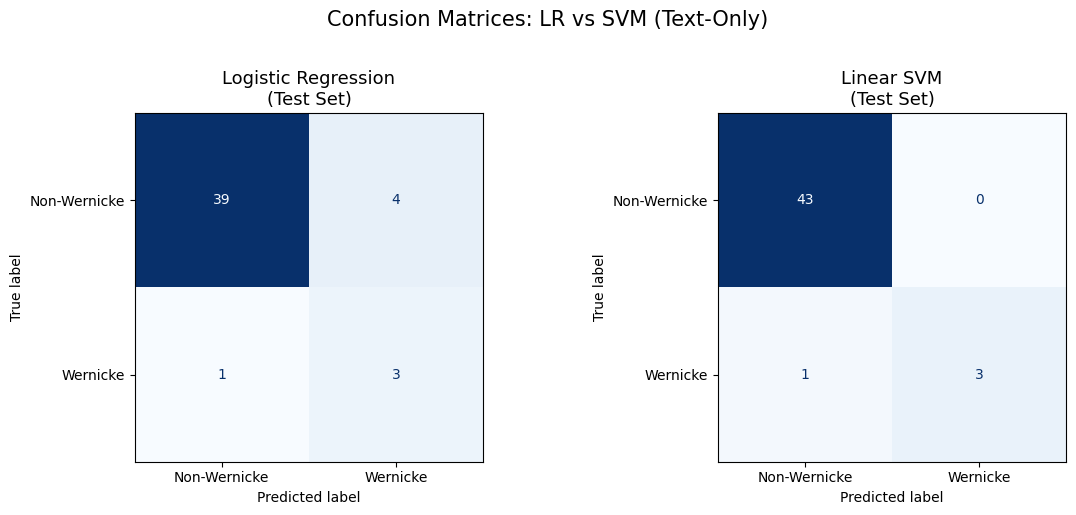

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


fig, axes = plt.subplots(1, 2, figsize=(12, 5))


for ax, y_pred, title in zip(axes, [lr_y_pred, svm_y_pred], ["Logistic Regression", "Linear SVM"]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Wernicke", "Wernicke"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{title}\n(Test Set)", fontsize=13)


plt.suptitle("Confusion Matrices: LR vs SVM (Text-Only)", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices_text_only.png", bbox_inches="tight", dpi=150)
plt.show()